In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/colabdatasets/Employee.csv")

df["Age"] = df["Age"].replace(0, np.nan)
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [2]:
df.dtypes
df['Age']=df['Age'].astype(int)

In [3]:
df.dtypes

,0
Company,object
Age,int64
Salary,float64
Place,object
Country,object
Gender,int64


In [4]:
df.isna().sum()

,0
Company,8
Age,0
Salary,24
Place,14
Country,0
Gender,0


In [5]:
#Filling missing values
df['Company']=df['Company'].fillna("Unknown")
df['Salary']=df['Salary'].fillna(np.mean(df['Salary']))
df['Place']=df['Place'].fillna(df['Place'].mode()[0])

In [6]:
df.isna().sum()

,0
Company,0
Age,0
Salary,0
Place,0
Country,0
Gender,0


In [7]:
df['Company'].unique()

array(['TCS', 'Infosys', 'CTS', 'Unknown', 'Tata Consultancy Services',
       'Congnizant', 'Infosys Pvt Lmt'], dtype=object)

In [8]:
df.describe()

,Age,Salary,Gender
count,148.000000,148.000000,148.000000
mean,31.804054,5312.467742,0.222973
std,8.271465,2354.305003,0.417654
min,17.000000,1089.000000,0.000000
25%,23.000000,3149.250000,0.000000
50%,31.000000,5312.467742,0.000000
75%,36.000000,7084.000000,0.000000
max,54.000000,9876.000000,1.000000


In [9]:
df.duplicated().sum()

np.int64(4)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.reset_index(drop=True)

,Company,Age,Salary,Place,Country,Gender
0,TCS,20,5312.467742,Chennai,India,0
1,Infosys,30,5312.467742,Mumbai,India,0
2,TCS,35,2300.000000,Calcutta,India,0
3,Infosys,40,3000.000000,Delhi,India,0
4,TCS,23,4000.000000,Mumbai,India,0
...,...,...,...,...,...,...
139,Infosys Pvt Lmt,22,8202.000000,Mumbai,India,0
140,TCS,33,9024.000000,Calcutta,India,1
141,Infosys,44,4034.000000,Delhi,India,1
142,TCS,33,5034.000000,Mumbai,India,1


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

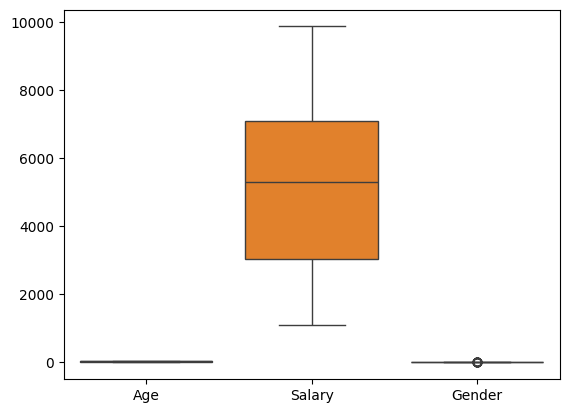

In [13]:
sns.boxplot(data=df)

In [14]:
#Finding outliers
Q1=np.percentile(df['Age'],25)
Q3=np.percentile(df['Age'],75)
IQR=Q3-Q1

In [15]:
lb=Q1-1.5*IQR
ub=Q3+1.5*IQR
print(lb)
print(ub)

5.375
54.375


In [16]:
outliers=df[(df['Age']<lb)|(df['Age']>ub)]
outliers #No ouliers presnt

,Company,Age,Salary,Place,Country,Gender


<Axes: ylabel='Gender'>

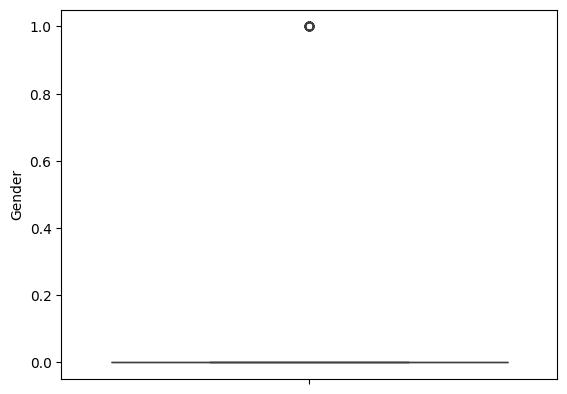

In [17]:
sns.boxplot(df['Gender']) #since there are only 2 values no outliers to remove

In [18]:
#data with age >40 and salary<5000
df1=df[(df['Age']>40) & (df['Salary']<5000)]

<Axes: xlabel='Age', ylabel='Salary'>

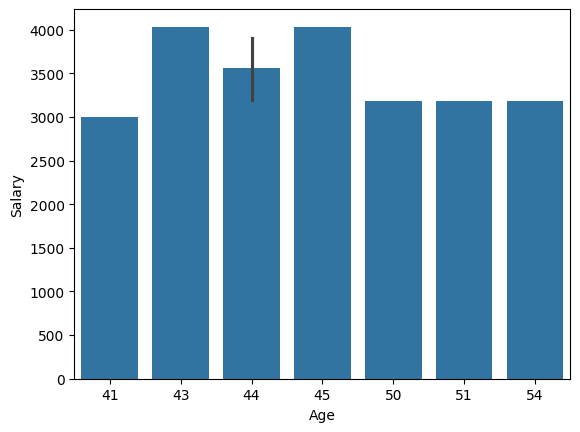

In [19]:
sns.barplot(data=df1,x="Age",y="Salary") #chart with age and salary

<Axes: xlabel='Place', ylabel='count'>

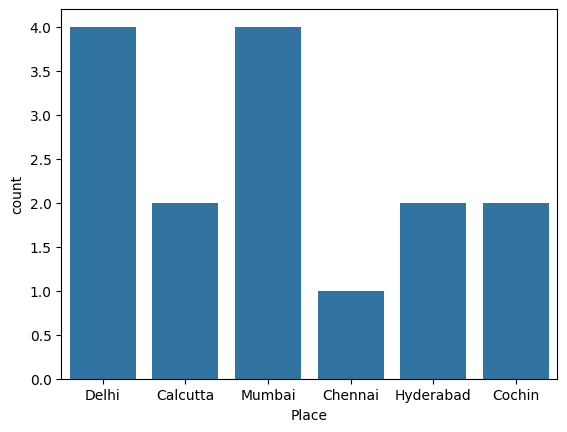

In [20]:
sns.countplot(data=df1,x="Place")# Count of the number of people from each place

In [21]:
#one hot encoding on Company
df = pd.get_dummies(df, columns=["Company"], drop_first=True,dtype=int)

In [22]:
#one hot encoding on place
df = pd.get_dummies(df, columns=["Place"], drop_first=True,dtype=int)


In [23]:
df

,Age,Salary,Country,Gender,Company_Congnizant,Company_Infosys,Company_Infosys Pvt Lmt,Company_TCS,Company_Tata Consultancy Services,Company_Unknown,Place_Calcutta,Place_Chennai,Place_Cochin,Place_Delhi,Place_Hyderabad,Place_Mumbai,Place_Nagpur,Place_Noida,Place_Podicherry,Place_Pune
0,20,5312.467742,India,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
1,30,5312.467742,India,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,35,2300.000000,India,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
3,40,3000.000000,India,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,23,4000.000000,India,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,22,8202.000000,India,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
143,33,9024.000000,India,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
145,44,4034.000000,India,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
146,33,5034.000000,India,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0


In [24]:
#Every employee belongs to the same country, so the column has no variation and won't help a machine learning mode
df.drop("Country", axis=1, inplace=True)

In [25]:
df #all values are encoded

,Age,Salary,Gender,Company_Congnizant,Company_Infosys,Company_Infosys Pvt Lmt,Company_TCS,Company_Tata Consultancy Services,Company_Unknown,Place_Calcutta,Place_Chennai,Place_Cochin,Place_Delhi,Place_Hyderabad,Place_Mumbai,Place_Nagpur,Place_Noida,Place_Podicherry,Place_Pune
0,20,5312.467742,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
1,30,5312.467742,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,35,2300.000000,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
3,40,3000.000000,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,23,4000.000000,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,22,8202.000000,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
143,33,9024.000000,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
145,44,4034.000000,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
146,33,5034.000000,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0


In [26]:
#Let salary is the output to be predicted and Other featurees are the inputs

In [27]:
X=df.drop("Salary",axis=1)
y=df["Salary"]

In [28]:
#Standardascaling
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_scaled=scalar.fit_transform(X)


In [29]:
print(X_scaled)
print(y)


[[-1.44554629 -0.53452248 -0.11867817 ... -0.24253563 -0.14586499
  -0.11867817]
 [-0.22824415 -0.53452248 -0.11867817 ... -0.24253563 -0.14586499
  -0.11867817]
 [ 0.38040692 -0.53452248 -0.11867817 ... -0.24253563 -0.14586499
  -0.11867817]
 ...
 [ 1.47597884  1.87082869 -0.11867817 ... -0.24253563 -0.14586499
  -0.11867817]
 [ 0.13694649  1.87082869 -0.11867817 ... -0.24253563 -0.14586499
  -0.11867817]
 [-1.20208586 -0.53452248 -0.11867817 ... -0.24253563 -0.14586499
  -0.11867817]]
0      5312.467742
1      5312.467742
2      2300.000000
3      3000.000000
4      4000.000000
          ...     
142    8202.000000
143    9024.000000
145    4034.000000
146    5034.000000
147    8202.000000
Name: Salary, Length: 144, dtype: float64


In [32]:
#scaling using minmax scaler
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler()
X_scaled_2=scalar.fit_transform(X)
print(X_scaled_2)

[[0.08108108 0.         0.         ... 0.         0.         0.        ]
 [0.35135135 0.         0.         ... 0.         0.         0.        ]
 [0.48648649 0.         0.         ... 0.         0.         0.        ]
 ...
 [0.72972973 1.         0.         ... 0.         0.         0.        ]
 [0.43243243 1.         0.         ... 0.         0.         0.        ]
 [0.13513514 0.         0.         ... 0.         0.         0.        ]]
